# **Predictive alerting for cloud metrics**

---

*Implement a model that predicts whether an incident will occur within the next H time steps based on the previous W steps of one or more time-series metrics. Use a sliding-window formulation and train the model using any standard machine-learning framework.*

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve
import lightgbm as lgb

import warnings
warnings.filterwarnings('ignore')

First, we need to generate data - I chose to follow a basic route of CPU crash, so I am going to generate this data

In [2]:
np.random.seed(42)

n_steps = 7000

time_axis = np.linspace(0, 25 * np.pi, n_steps)
cpu_load = 50 + 10 * np.sin(time_axis) + 3 * np.random.randn(n_steps)

incidents = np.zeros(n_steps)

anomalies = np.random.choice(range(77, n_steps - 77), size = 50, replace = False)

for idx in anomalies:
    cpu_load[idx-10:idx] += np.linspace(5, 25, 10)
    incidents[idx] = 1

The noise will be set to **3**, while the anomaly growth will be set to **5 to 25**

In [3]:
df = pd.DataFrame({
    'timestamp': range(n_steps),
    'cpu_load': cpu_load,
    'is_incident': incidents
})

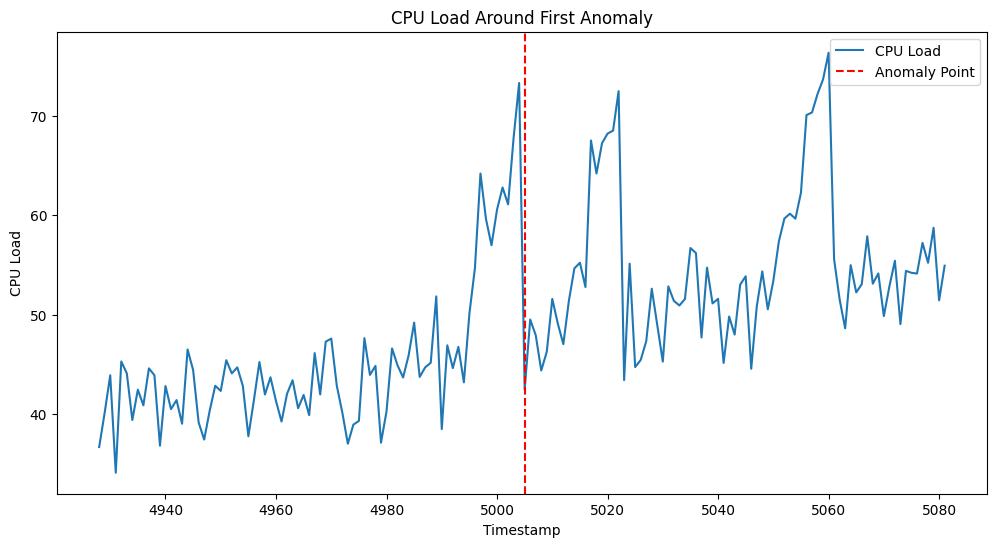

In [4]:
first_anomaly = anomalies[0]
slice_df = df.iloc[first_anomaly-77:first_anomaly+77]

plt.figure(figsize=(12, 6))
plt.plot(slice_df['timestamp'], slice_df['cpu_load'], label='CPU Load')
plt.axvline(x=first_anomaly, color='red', linestyle='--', label='Anomaly Point')
plt.xlabel('Timestamp')
plt.ylabel('CPU Load')
plt.title('CPU Load Around First Anomaly')
plt.legend()
plt.show()

Now that the data is generated, I will use a Sliding Window formulation and split the data

In [5]:
W = 30
H = 10

X, y = [], []

In [6]:
for i in range(len(df) - W - H):
    window = df['cpu_load'].iloc[i:i+W].values
    X.append(window)

    label = df['is_incident'].iloc[i+W:i+W+H].max()
    y.append(label)

In [7]:
X = np.array(X)
y = np.array(y)

print(f"X shape is {X.shape} and y shape is {y.shape}")
print(f"Incident number is {sum(y)}")

X shape is (6960, 30) and y shape is (6960,)
Incident number is 486.0


We can see that we have 486 positive samples, which is not very realistic, being 7% of a whole time series. If I replicated a realistic < 1% or even < 0.5%, the Random Forest would most likely fail.

Now I will split the data into train/test. Due to the fact that this is a time-series data, we cannot split it randomly, so I willl choose first 80% of timeline to be a train data and last 20% to be a test data.

In [8]:
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [9]:
print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")

Training set size: 5568
Test set size: 1392


I will use a **Random Forest Classifier** for this demonstration. With real-world data I would preferrably use a model specifically formulated for very unbalanced time-series incident data (as usually occurs in realistic data), but as the task states the dataset complexity is not important here, I chose this algorithm as it is robust to noise and unscaled data.

In [10]:
clf = RandomForestClassifier(
    n_estimators=200,
    random_state=42, 
    max_depth = 5,
    class_weight='balanced',
    n_jobs=1
)
clf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=5, n_estimators=200,
                       n_jobs=1, random_state=42)

In [11]:
y_pred = clf.predict(X_test)
y_probs = clf.predict_proba(X_test)[:, 1]

print("Statistics for Random Forest:")

print(confusion_matrix(y_test, y_pred))

print(classification_report(y_test, y_pred))

Statistics for Random Forest:
[[1262   17]
 [  23   90]]
              precision    recall  f1-score   support

         0.0       0.98      0.99      0.98      1279
         1.0       0.84      0.80      0.82       113

    accuracy                           0.97      1392
   macro avg       0.91      0.89      0.90      1392
weighted avg       0.97      0.97      0.97      1392



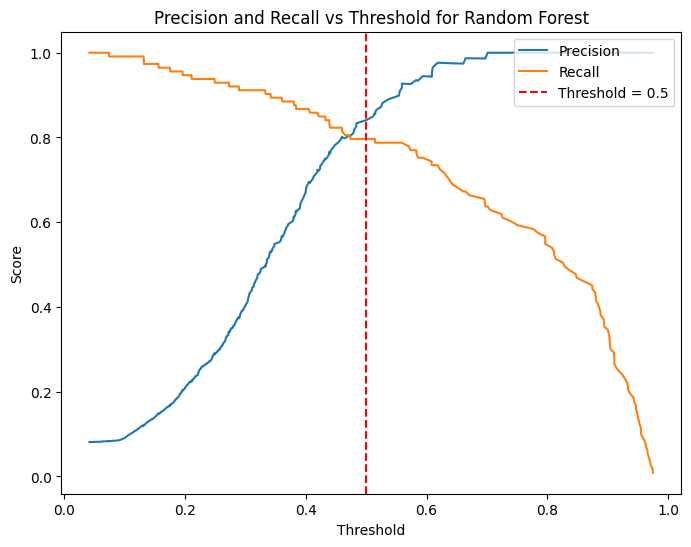

In [12]:
precision, recall, threshold = precision_recall_curve(y_test, y_probs)

plt.figure(figsize=(8, 6))
plt.plot(threshold, precision[:-1], label='Precision')
plt.plot(threshold, recall[:-1], label='Recall')
plt.axvline(x=0.5, label='Threshold = 0.5', color='red', linestyle='--')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.legend(loc = 'upper right')
plt.title('Precision and Recall vs Threshold for Random Forest')
plt.show()

Now I would like to try to use LighGBM model, which is a more standard approach for time-series predictions. Later, I will compare these 2 models' performance based on the metrics

In [13]:
clf2 = lgb.LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42,
    max_depth=8,
    num_leaves=24,
    class_weight='balanced',
    n_jobs=1
)

clf2.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 373, number of negative: 5195
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001064 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 5568, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


LGBMClassifier(class_weight='balanced', learning_rate=0.05, max_depth=8,
               n_estimators=200, n_jobs=1, num_leaves=24, random_state=42)

In [14]:
y_pred2 = clf2.predict(X_test)
y_probs2 = clf2.predict_proba(X_test)[:, 1]

print("Statistics for LightGBM:")

print(confusion_matrix(y_test, y_pred2))

print(classification_report(y_test, y_pred2))

Statistics for LightGBM:
[[1268   11]
 [  19   94]]
              precision    recall  f1-score   support

         0.0       0.99      0.99      0.99      1279
         1.0       0.90      0.83      0.86       113

    accuracy                           0.98      1392
   macro avg       0.94      0.91      0.93      1392
weighted avg       0.98      0.98      0.98      1392



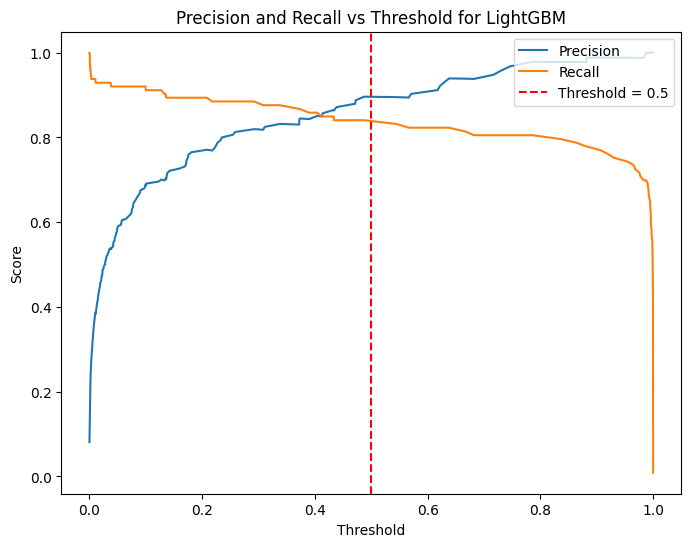

In [15]:
precision2, recall2, threshold2 = precision_recall_curve(y_test, y_probs2)

plt.figure(figsize=(8, 6))
plt.plot(threshold2, precision2[:-1], label='Precision')
plt.plot(threshold2, recall2[:-1], label='Recall')
plt.axvline(x=0.5, label='Threshold = 0.5', color='red', linestyle='--')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.legend(loc = 'upper right')
plt.title('Precision and Recall vs Threshold for LightGBM')
plt.show()

## Model Comparison: Random Forest vs. LightGBM


To ensure a fair and rigorous evaluation, I trained and hyperparameter-tuned both tree-based architectures: a bagging ensemble (**Random Forest**) and a gradient boosting framework (**LightGBM**). 

Here is the comparison of their performance on the minority class (`Class 1.0` - Incidents):

| Metric / Outcome | Random Forest (Tuned) | LightGBM (Tuned) | Impact of LightGBM |
| :--- | :--- | :--- | :--- |
| **True Positives (Caught Incidents)** | 90 | **94** | Caught 4 additional incident windows. |
| **False Negatives (Missed Incidents)**| 23 | **19** | Reduced missed crashes by ~17%. |
| **False Positives (False Alarms)**| 17 | **11** | Reduced false alarms by ~35%. |
| **Precision** | 0.84 | **0.90** | Significantly more reliable alerts. |
| **Recall** | 0.80 | **0.83** | Better overall sensitivity to anomalies. |
| **F1-Score** | 0.82 | **0.86** | Superior overall balance. |

Based on this statistics, a tined LightGBM is a winner :)